# 04 — Markov Random Field (Ising V1)

Méthode-clé de la thèse : **modèle d'Ising binaire** avec voisinage sur la
grille des plants. Le champ latent ``y_i ∈ {0, 1}`` représente la
présence/absence de pucerons, conditionné aux observations binarisées des
capteurs. L'inférence se fait par échantillonneur de Gibbs en damier ; les
paramètres ``(α, β)`` sont soit fournis, soit estimés par
pseudo-vraisemblance.

On procède en trois étapes :

1. **Validation sur petite grille 20×20** avec paramètres connus.
2. **Application au champ complet** comparée au krigeage ordinaire.
3. **Sensibilité au seuil de binarisation** des observations capteurs.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import expit

from aphid_spatial.evaluation.metrics import evaluate_all
from aphid_spatial.methods.geostatistics import OrdinaryKrigingIndicator
from aphid_spatial.methods.lattice import (
    IsingMRF,
    checkerboard_mask,
    gibbs_one_color,
)
from aphid_spatial.simulation import (
    Field,
    FieldConfig,
    SensorConfig,
    place_sensors,
    simulate_field,
)
from aphid_spatial.visualization.maps import plot_field, plot_prediction

logging.basicConfig(level=logging.WARNING, format="%(name)s | %(message)s")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Validation sur grille 20×20 avec α/β connus

Sur une grille libre (sans conditionnement aux capteurs), avec
``α = logit(0.3)`` et ``β = 0`` (pas d'interaction), la prévalence des
échantillons doit converger vers ``σ(α) ≈ 0.3``. Avec ``β > 0``, on observe
des structures de clusters.

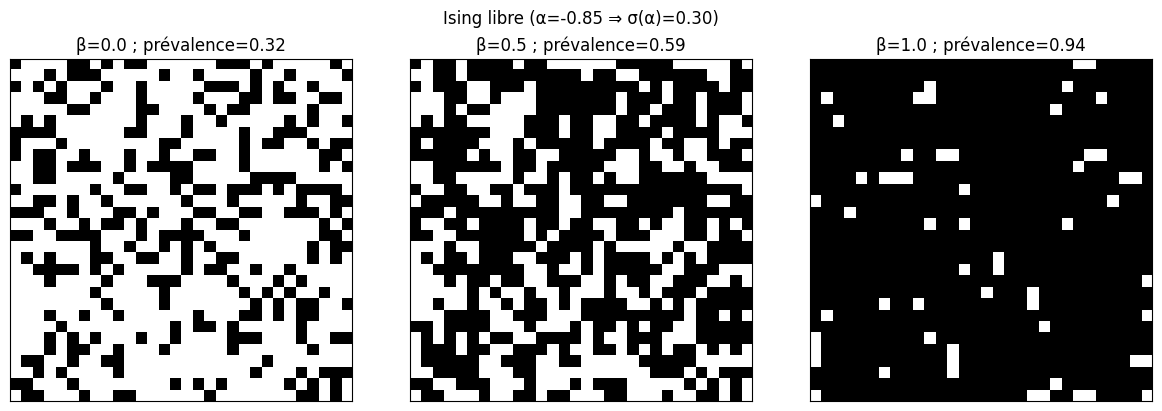

In [2]:
rng = np.random.default_rng(0)
n = 30  # grille 30x30
alpha_true = float(np.log(0.3 / 0.7))  # logit(0.3)
no_sensor_mask = np.zeros((n, n), dtype=bool)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, beta in zip(axes, [0.0, 0.5, 1.0], strict=True):
    y = (rng.random((n, n)) < 0.3).astype(np.int8)
    black = checkerboard_mask(n, n)
    white = ~black
    rng_iter = np.random.default_rng(42)
    for _ in range(800):
        gibbs_one_color(y, black, no_sensor_mask, alpha_true, beta, queen=False, rng=rng_iter)
        gibbs_one_color(y, white, no_sensor_mask, alpha_true, beta, queen=False, rng=rng_iter)
    ax.imshow(y, cmap="Greys", origin="lower")
    ax.set_title(f"β={beta:.1f} ; prévalence={y.mean():.2f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Ising libre (α={alpha_true:.2f} ⇒ σ(α)={expit(alpha_true):.2f})")
fig.savefig(FIG_DIR / "04_lattice_mrf_validation.png", dpi=150)
plt.show()

## B. Application au champ complet (vs krigeage ordinaire)

L'Ising V1 conditionné aux 20 capteurs uniformes.

In [3]:
data_path = Path("../data/simulated/field_default.npz")
if data_path.exists():
    field = Field.load(data_path)
else:
    field = simulate_field(FieldConfig(seed=42))

readings = place_sensors(
    field, SensorConfig(n_sensors=20, placement="uniform", n_observations=50, seed=2024)
)

ising = IsingMRF(neighborhood="queen", n_burn=100, n_samples=300, seed=0)
ising.fit(readings, field)
p_ising = ising.predict_proba(field.coords)
print(f"Ising params: {ising.params}")

ok = OrdinaryKrigingIndicator()
ok.fit(readings, field)
p_ok = ok.predict_proba(field.coords)

print("\n=== Comparaison Ising vs OK indicator ===")
for name, p in (("ising_v1", p_ising), ("ok_indicator", p_ok)):
    m = evaluate_all(field.presence, p, p_true=field.prob)
    print(f"{name:>14} : AUC={m['auc_roc']:.3f}, Brier={m['brier']:.3f}, MAE={m['mae_prob']:.3f}")

Ising params: {'alpha': -1.1132553883546645, 'beta': -0.014415177242426472, 'fit_seconds': 8.349929500021972, 'n_iter_kept': 300}

=== Comparaison Ising vs OK indicator ===


      ising_v1 : AUC=0.500, Brier=0.183, MAE=0.142
  ok_indicator : AUC=0.672, Brier=0.170, MAE=0.105


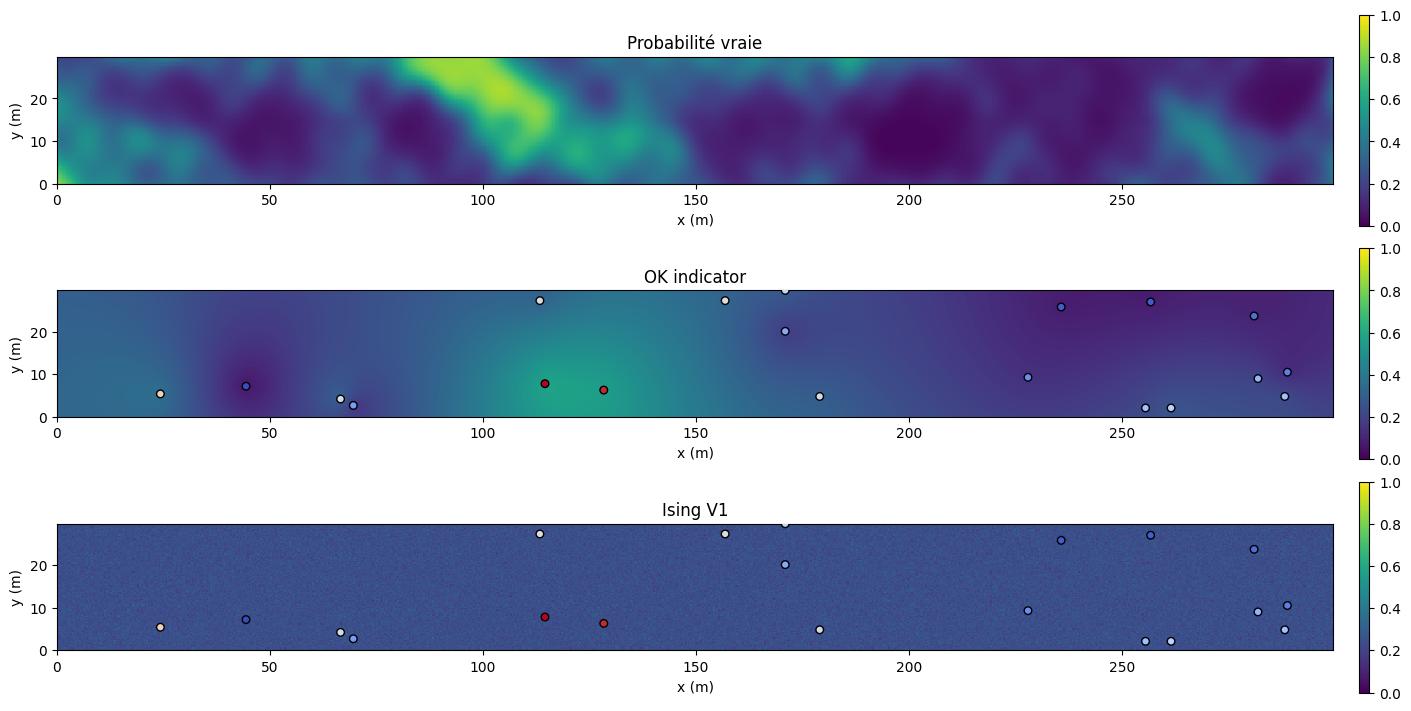

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), constrained_layout=True)
plot_field(field, "prob", ax=axes[0], title="Probabilité vraie")
plot_prediction(p_ok, field, ax=axes[1], readings=readings, title="OK indicator")
plot_prediction(p_ising, field, ax=axes[2], readings=readings, title="Ising V1")
fig.savefig(FIG_DIR / "04_lattice_mrf_maps.png", dpi=150)
plt.show()

## C. Sensibilité au seuil de binarisation

Le seuil de binarisation des observations capteurs (``threshold``) influe
sur le conditionnement Ising. Avec ``threshold = 0.3``, plus de capteurs
sont conditionnés à 1 ; avec ``threshold = 0.7``, peu le sont.

**Note** : la version V1 est connue pour être instable avec sparsité de
capteurs (~20 sur 100k cellules) ; la pseudo-vraisemblance estime souvent
``β ≈ 0``, ce qui rend l'Ising proche d'une simple baseline. Une V2 avec
estimation EM (alterner inférence et estimation) ou ``β`` fixé est prévue
dans un round ultérieur.

In [5]:
import pandas as pd
rows = []
for thr in (0.3, 0.5, 0.7):
    m = IsingMRF(neighborhood="queen", threshold=thr, n_burn=100, n_samples=200, seed=0)
    m.fit(readings, field)
    p = m.predict_proba(field.coords)
    metrics = evaluate_all(field.presence, p, p_true=field.prob)
    rows.append({
        "threshold": thr,
        "alpha_est": m.params["alpha"],
        "beta_est": m.params["beta"],
        "auc_roc": metrics["auc_roc"],
        "mae_prob": metrics["mae_prob"],
        "prevalence_pred": metrics["prevalence_pred"],
    })
pd.DataFrame(rows)

,threshold,alpha_est,beta_est,auc_roc,mae_prob,prevalence_pred
0,0.3,-1.113398,-0.014423,0.501431,0.142726,0.242313
1,0.5,-1.113255,-0.014415,0.501456,0.142724,0.242310
2,0.7,-1.113674,-0.014407,0.501549,0.142708,0.242220
